# Bioinformatic De-confounding
 Continuing from 02_EDA IPYNB 
### Goal:
 Quantify the "Myogenic Clock",
 Score Cell Cycle Status ,
 Covariate Modeling & Regression 


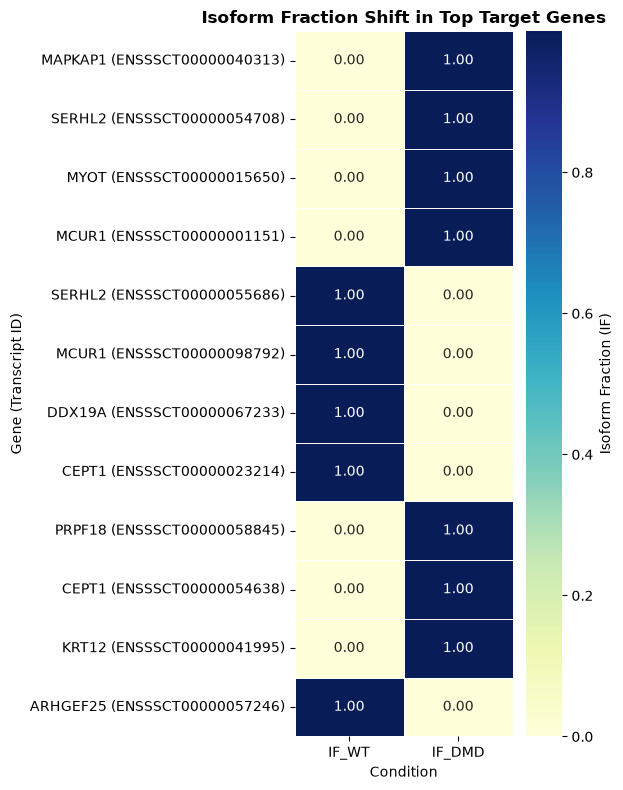

In [ ]:
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Load the dataset and display the first 10 rows
# Note: Set index_col=0 if the first column contains exon/sample IDs rather than data
df = pd.read_csv('../data/processed/splicing_matrix.csv')

# compares the two condition columns horizontally
# for every single row and saves the larger number into a new colum
df['max_TPM'] = df[['mean_TPM_WT', 'mean_TPM_DMD']].max(axis=1)

# Calculate change in Isoform Fraction
df['delta_IF'] = df['IF_DMD'] - df['IF_WT']

# Pick top 8 multi-isoform genes with highest isoform shifts
multi_genes = df['Gene_ID'].value_counts()
multi_genes = multi_genes[multi_genes >= 2].index

candidate_txs = (
    df[(df['Gene_ID'].isin(multi_genes)) & (df['max_TPM'] >= 1.0)]
    .sort_values(by="delta_IF", key=abs, ascending=False)
    .head(12)
)

# Prepare label: "Gene_Name - Transcript_ID"
candidate_txs["Label"] = candidate_txs["Gene_Name"] + " (" + candidate_txs["Transcript_ID"] + ")"
heatmap_data = candidate_txs.set_index("Label")[["IF_WT", "IF_DMD"]]

plt.figure(figsize=(6, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Isoform Fraction (IF)'},
    linewidths=0.5
)

plt.title("Isoform Fraction Shift in Top Target Genes", fontsize=12, fontweight="bold")
plt.ylabel("Gene (Transcript ID)")
plt.xlabel("Condition")
plt.tight_layout()
plt.show()

## gene expression for each marker across all six individual SRA runs

In [6]:
import pandas as pd

# Load your aggregated matrix
df = pd.read_csv('../data/processed/splicing_matrix.csv')

# Define run groups
wt_runs = ["SRR32086846", "SRR32086848", "SRR32086850"]
dmd_runs = ["SRR32086830", "SRR32086832", "SRR32086836"]
sample_cols = wt_runs + dmd_runs

# Panel 1: Myogenic Differentiation Clock
myogenic_markers = ["PAX7", "MYF5", "MYOD1", "MYOG", "MYH1", "CKM"]

# Panel 2: Cell Cycle & Proliferation Markers
cell_cycle_markers = ["MKI67", "TOP2A", "PCNA", "CDK1", "CDKN1A"]

target_genes = myogenic_markers + cell_cycle_markers

# Filter for marker genes and sum transcript TPMs up to Gene level
gene_tpm = (
    df[df["Gene_Name"].isin(target_genes)]
    .groupby("Gene_Name")[sample_cols]
    .sum()
)

# Calculate condition averages for quick comparison
gene_tpm["WT_mean"] = gene_tpm[wt_runs].mean(axis=1)
gene_tpm["DMD_mean"] = gene_tpm[dmd_runs].mean(axis=1)

print(gene_tpm.round(2))

           SRR32086846  SRR32086848  SRR32086850  SRR32086830  SRR32086832  \
Gene_Name                                                                    
CDK1              0.00         0.34         0.00         0.00         0.31   
CDKN1A          244.04       188.13       146.38       323.63       301.19   
CKM               4.25         2.34         0.69        12.90         9.69   
MYF5              2.44         2.98         2.37        98.71       110.05   
MYH1              0.00         0.00         0.00         0.62         0.00   
MYOD1             1.79         0.67         0.62         5.09         4.27   
MYOG              6.14         5.90         4.41        57.54        45.24   
PAX7              0.16         0.00         0.00         3.56         1.64   
PCNA             17.57        14.16        12.33        14.23         8.97   
TOP2A             4.36         3.59         2.03         3.59         1.42   

           SRR32086836  WT_mean  DMD_mean  
Gene_Name          

# Quantifying the "Myogenic Clock"

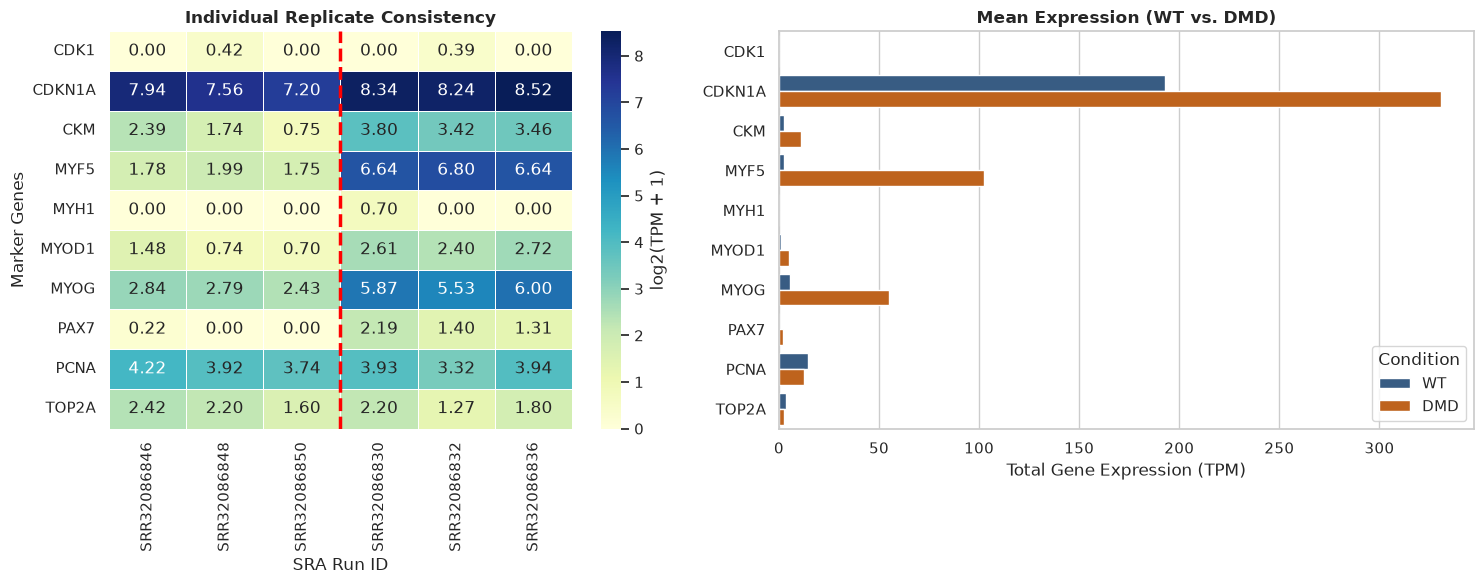

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.2]})

# ----------------------------------------------------
# 1. Heatmap: Log-transformed TPMs across all 6 runs
# ----------------------------------------------------
log_tpm = np.log2(gene_tpm[sample_cols] + 1)

sns.heatmap(
    log_tpm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "log2(TPM + 1)"},
    ax=axes[0],
    linewidths=0.5,
)
axes[0].set_title("Individual Replicate Consistency", fontsize=12, fontweight="bold")
axes[0].set_xlabel("SRA Run ID")
axes[0].set_ylabel("Marker Genes")

# Highlight group boundary visually on the heatmap
axes[0].axvline(3, color="red", linewidth=2.5, linestyle="--")  # Separates WT from DMD

# ----------------------------------------------------
# 2. Grouped Bar Chart: WT_mean vs DMD_mean
# ----------------------------------------------------
mean_df = gene_tpm[["WT_mean", "DMD_mean"]].reset_index()
melted_df = mean_df.melt(
    id_vars="Gene_Name", var_name="Condition", value_name="TPM"
)

# Clean up label names for plot legend
melted_df["Condition"] = melted_df["Condition"].replace(
    {"WT_mean": "WT", "DMD_mean": "DMD"}
)

sns.barplot(
    data=melted_df,
    x="TPM",
    y="Gene_Name",
    hue="Condition",
    palette={"WT": "#2b5c8f", "DMD": "#d95f02"},
    ax=axes[1],
)
axes[1].set_title("Mean Expression (WT vs. DMD)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total Gene Expression (TPM)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Running ssGSEA against MSigDB Hallmark sets...
[✓] Matched 4 target pathways: ['Apoptosis', 'E2F Targets', 'Myogenesis', 'p53 Pathway']


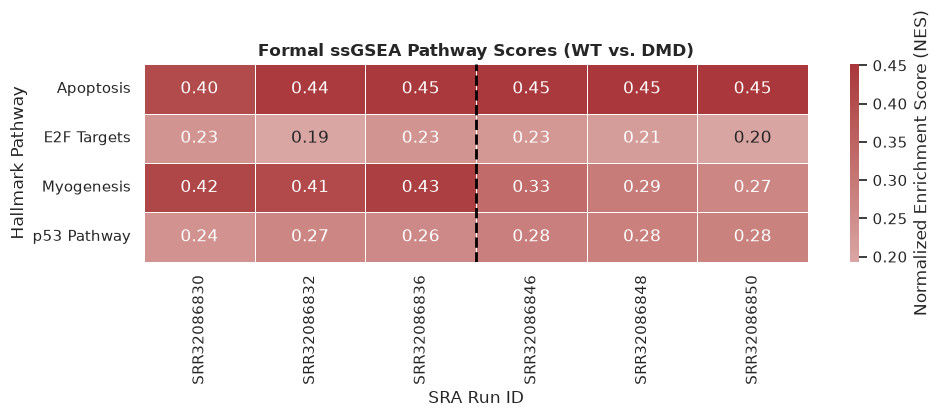

In [9]:
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load data and aggregate transcript TPMs to Gene level
df = pd.read_csv("../data/processed/splicing_matrix.csv")

wt_runs = ["SRR32086846", "SRR32086848", "SRR32086850"]
dmd_runs = ["SRR32086830", "SRR32086832", "SRR32086836"]
sample_cols = wt_runs + dmd_runs

# Ensure gene symbols are uppercase strings for MSigDB matching
df["Gene_Name_Clean"] = df["Gene_Name"].dropna().astype(str).str.upper()

# Group transcripts by Gene_Name and sum TPMs
gene_df = (
    df.dropna(subset=["Gene_Name_Clean"])
    .groupby("Gene_Name_Clean")[sample_cols]
    .sum()
)

# Filter low-expressed genes across samples
gene_df = gene_df[gene_df.sum(axis=1) > 1]

# 2. Run Single-Sample GSEA using MSigDB Hallmark Gene Sets
print("Running ssGSEA against MSigDB Hallmark sets...")
ss_res = gp.ssgsea(
    data=gene_df,
    gene_sets="MSigDB_Hallmark_2020",
    outdir=None,
    sample_norm_method="rank",
    min_size=5,
    no_plot=True,
)

# 3. Pivot results into a Pathway x Sample Score Matrix
scores_df = ss_res.res2d.pivot(index="Term", columns="Name", values="NES")

# Substring matching for target pathways to avoid string-mismatch errors
keywords = ["E2F", "G2M", "MYOGENESIS", "P53", "APOPTOSIS"]
matched_terms = [
    term
    for term in scores_df.index
    if any(kw in term.upper() for kw in keywords)
]

print(f"[✓] Matched {len(matched_terms)} target pathways: {matched_terms}")

if len(matched_terms) == 0:
    print(
        "Warning: No keyword matches found. Top available pathway terms in scores_df:"
    )
    print(list(scores_df.index[:10]))
else:
    plot_df = scores_df.loc[matched_terms]

    # 4. Visualize Pathway Scores
    plt.figure(figsize=(10, max(4, len(matched_terms) * 0.8)))
    sns.heatmap(
        plot_df,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Normalized Enrichment Score (NES)"},
    )
    plt.title("Formal ssGSEA Pathway Scores (WT vs. DMD)", fontweight="bold")
    plt.xlabel("SRA Run ID")
    plt.ylabel("Hallmark Pathway")
    plt.axvline(3, color="black", linewidth=2, linestyle="--")  # WT vs DMD split
    plt.tight_layout()
    plt.show()